corresponding to archive-45

In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

ub:lbd0us, mean:0.362868817038287
ub:lbd1us, mean:0.362868817038287
ub:lbd2us, mean:0.362868817038287
ub:lbd3us, mean:0.362868817038287
count:1/5 facebook_1000_W.pdf completed.


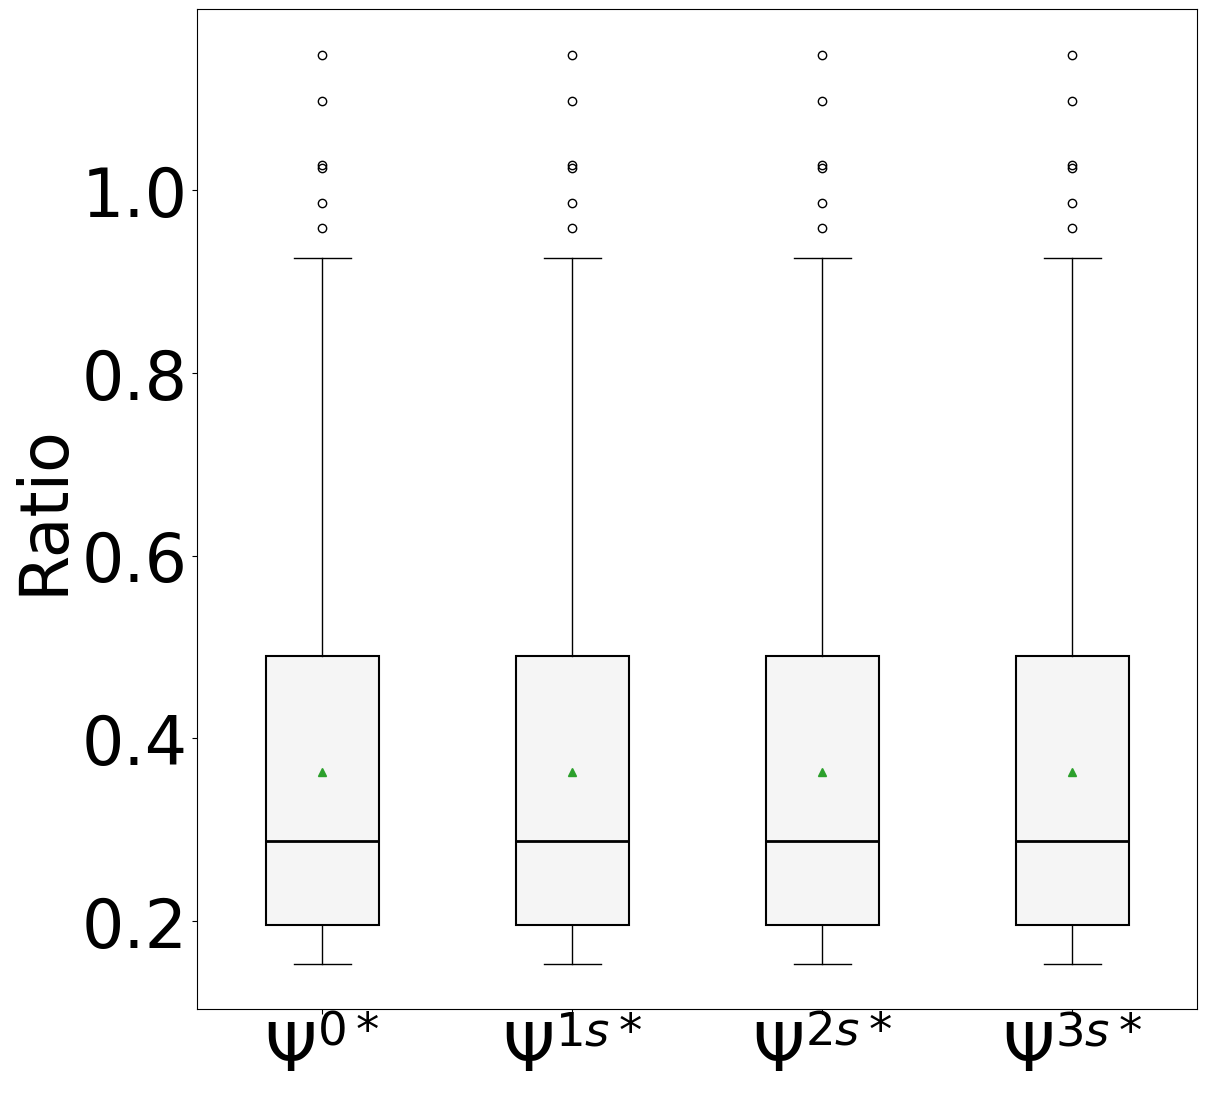

In [ ]:
t = 'W'

def load_12_series(algo: str, upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        # print(f"name:{name}")
        if not os.path.isdir(os.path.join(source_dir, name)):
            format = name.strip()[:-5].split('-')
            if len(format) == 5:
                alg, up, task, budget, _ = name.strip()[:-5].split('-')
                # algo, up, task, b = name.strip()[:-5].split('-')
                # print(f"u:{upper_bound}, t:{task_name}, up:{up}, task:{task}")
                
                if alg == algo and up == upper_bound and task_dict[task_name] == task:
                    # print(name)
                    file_path = os.path.join(source_dir, name)
                    with open(file_path, "rb") as rd:
                        kv_data = pickle.load(rd)
                    # print(kv_data)
                    if t == 'T':
                        res.append( (eval(budget), kv_data['f(S)'], kv_data['upb'], kv_data['time']))
                    elif t == '':
                        res.append( (eval(budget), kv_data['f(S)'], kv_data['upb'], kv_data['AF']))      
                    elif t == 'W':
                        res.append( (eval(budget), kv_data['f(S)'], kv_data['upb'], kv_data['AF']/kv_data['worst']))      
    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['facebook']
# task_list = ['youtube']

# configuration_list = [
#     ('greedy_mintss','lbd0'),
#     ('greedy_mintss','lbd0s'),
#     ('augmented_greedy_mintss','lbd0'),
#     ('augmented_greedy_mintss','lbd0s'),
# ]
configuration_list = [
    ('greedy_mintss','lbd0us'),
    ('greedy_mintss','lbd1us'),
    ('greedy_mintss','lbd2us'),
    ('greedy_mintss','lbd3us'),
]


algorithm_dict = {
    'greedy_mintss': "",
    'augmented_greedy_mintss': "*",
}


ub_title_dict = {
    'lbd0': r"$\Psi^{0}$",
    'lbd0s': r"$\Psi^{0s}$",
    'lbd0us': r"$\Psi^{0*}$",
    'lbd1us': r"$\Psi^{1s*}$",
    'lbd2us': r"$\Psi^{2s*}$",
    'lbd3us': r"$\Psi^{3s*}$",
}

ub_title_list = [
    ub_title_dict[configuration[1]] + algorithm_dict[configuration[0]]    
    for configuration in configuration_list
]

archive_dir = "../result/archive-61"

result_dir = "./result_min_without"

n = 1000
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
for ub in configuration_list:
    u_data_list.append([])

seed_range = range(0, 20)
# b_range = range(10, 60, 5)
b_range = range(250, 500, 25)

b_data_list = []
for ub in configuration_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)

bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 3]

count = 0
total_count = len(task_list) + len(configuration_list) * len(task_list)

for task in task_list:
    for seed in seed_range:
        for config_idx in range(0, len(configuration_list)):
            # print(f"seed:{seed}")
            config = configuration_list[config_idx]
            algo = config[0]
            ub = config[1]

            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}")
            X, Y, Z, W = load_12_series(algo=algo, upper_bound=ub, task_name=task, source_dir=source_dir)

            for x_idx in range(0, len(X)):
                b = X[x_idx]
                if int(b) in b_range:
                    b_list_idx = bti_dict[b]
                    b_data_list[config_idx][b_list_idx].append(W[x_idx])    
                    u_data_list[config_idx].append(W[x_idx])


    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_axes([0,0,1,1])
    if t == '':
        ax.set_ylabel("Approximation guarantee")
    elif t == 'T':
        ax.set_ylabel("Computational time (s)")
    elif t == 'W':
        ax.set_ylabel("Ratio")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for config_idx in range(0, len(configuration_list)):
        ub = configuration_list[config_idx][1]
        print(f"ub:{ub}, mean:{np.mean(data[config_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")


    suffix = ""
    if t != '':
        suffix= "_" + t

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # second plot

    # fig = plt.figure(figsize=(10, 8))

    # ax = fig.add_axes([0,0,1,1])
    # ax.set_ylabel("Approximation factor")
    # # ax.set_ylabel("Computational time(s)")

    # box_props = dict(linewidth=1.5, color="black")
    # median_props = dict(linewidth=2)
    # mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    # whisker_props = {"color":"black"}

    # color_list = ["whitesmoke","wheat", 'cornsilk']

    # whisker_color_list = ["dimgray","orange",'cornsilk']
    # cc = 0

    # for i in ub_to_draw_list:
    #     data = b_data_list[i]
    #     ub = ub_list[i]

    #     flier_props["markerfacecolor"] = color_list[cc]
    #     whisker_props["color"] = whisker_color_list[cc]

    #     xtick_labels = []
    #     for b in b_range:
    #         if int(b) % 2 == 1:
    #             xtick_labels.append(b)
    #         else:
    #             xtick_labels.append(" ")

    #     bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
    #                     , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
    #     # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

    #     for median in bp["medians"]:
    #         median.set_color("black")
    #     for box in bp["boxes"]:
    #         box.set_facecolor(color_list[cc])

    #     cc = cc + 1

    #     plt.legend()
    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.jpg"), format='jpg', bbox_inches='tight')
    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.pdf"), format='pdf', bbox_inches='tight')
    #     count = count + 1
    #     print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

30, 15:
ub:lbd0, mean:9.200000000000001
ub:lbd0s, mean:1.0
ub:lbd0, mean:9.200000000000001
ub:lbd0s, mean:1.0
19,15:
ub:lbd0, mean:1.4000000000000001
ub:lbd0s, mean:1.0
ub:lbd0, mean:1.4000000000000001
ub:lbd0s, mean:1.0
10, 19:
ub:lbd0, mean:2.0117327566570484
ub:lbd0s, mean:2.0117327566570484
ub:lbd0, mean:1.8152921802259951
ub:lbd0s, mean:1.8152921802259951
total:
ub:lbd0, mean:1.85209276793371
ub:lbd0s, mean:1.623130300176683
ub:lbd0, mean:1.85209276793371
ub:lbd0s, mean:1.623130300176683